# **Additive Gaussian noise**

Epoch 1/50
391/391 [==============================] - 10s 17ms/step - loss: 0.0176 - val_loss: 0.0583
Epoch 2/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0114 - val_loss: 0.0540
Epoch 3/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0101 - val_loss: 0.0468
Epoch 4/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0092 - val_loss: 0.0403
Epoch 5/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0086 - val_loss: 0.0432
Epoch 6/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0082 - val_loss: 0.0347
Epoch 7/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0079 - val_loss: 0.0268
Epoch 8/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0077 - val_loss: 0.0318
Epoch 9/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0075 - val_loss: 0.0263
Epoch 10/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0073 - val_l

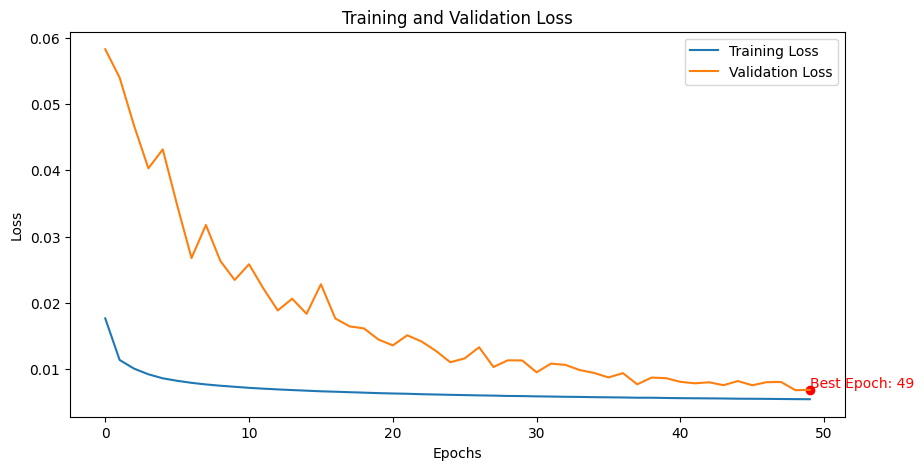

1/1 [==============================] - 0s 294ms/step
Average MSE: 0.00553649
Average SSIM: 0.7834934


<ipython-input-3-cc19d7f79901>:76: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])


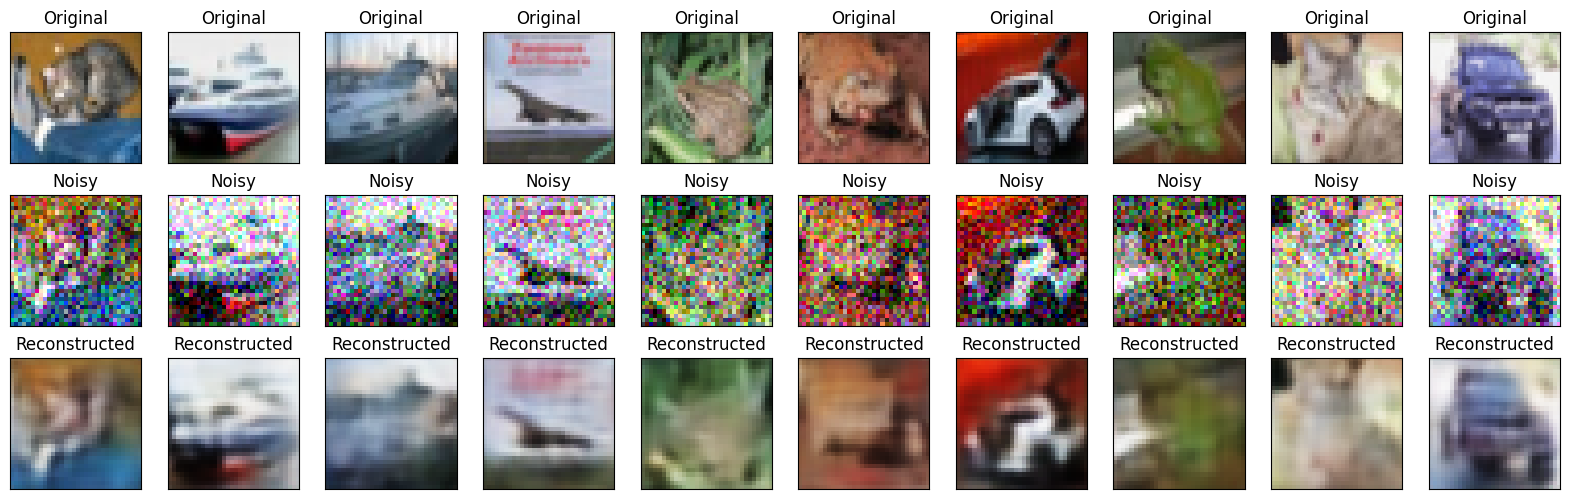

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.losses import MeanSquaredError

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add noise to the training set
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# Add noise to the first 10 test images for display
x_test_noisy = x_test[:10] + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test[:10].shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Define the autoencoder model
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x) # Bottleneck, now the data is (4, 4, 128)

# Decoder
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# Train the autoencoder
history = autoencoder.fit(x_train_noisy, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Evaluate Test Loss
test_loss = autoencoder.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.scatter(best_epoch, min(history.history['val_loss']), color='red')
plt.text(best_epoch, min(history.history['val_loss']), f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse = MeanSquaredError()
decoded_imgs = autoencoder.predict(x_test_noisy)
avg_mse = np.mean([mse(x_test[i], decoded_imgs[i]).numpy() for i in range(10)])
avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, noisy, and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


# **Hyper Parameter Tuning**

In [4]:
!pip install keras-tuner

Reloading Tuner from autoencoder_tuning/cifar10/tuner0.json
Epoch 1/50
391/391 [==============================] - 14s 29ms/step - loss: 0.0103 - val_loss: 0.0419
Epoch 2/50
391/391 [==============================] - 10s 24ms/step - loss: 0.0064 - val_loss: 0.0322
Epoch 3/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0058 - val_loss: 0.0220
Epoch 4/50
391/391 [==============================] - 9s 24ms/step - loss: 0.0054 - val_loss: 0.0204
Epoch 5/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0051 - val_loss: 0.0157
Epoch 6/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0049 - val_loss: 0.0133
Epoch 7/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0048 - val_loss: 0.0120
Epoch 8/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0047 - val_loss: 0.0105
Epoch 9/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0046 - val_loss: 0.0101
Epoch 10/50
391/391 [========

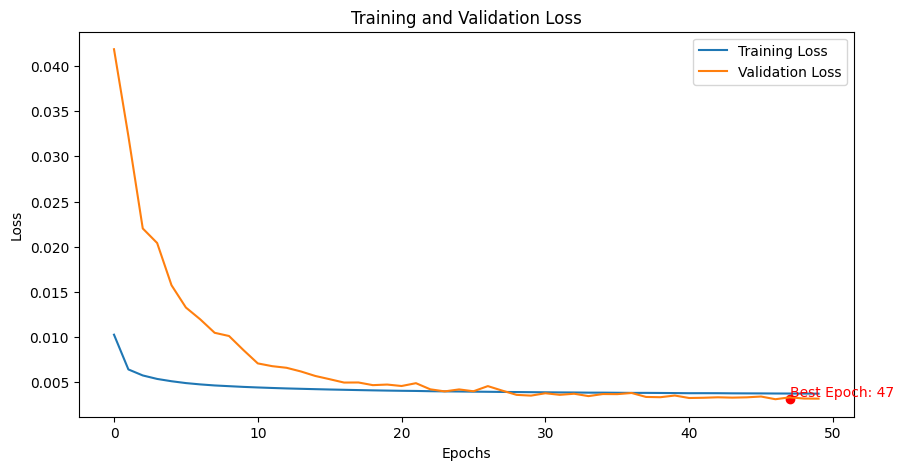

1/1 [==============================] - 0s 228ms/step
Average MSE: 0.003956451
Average SSIM: 0.8402171


<ipython-input-5-f7b9d78aae64>:93: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])


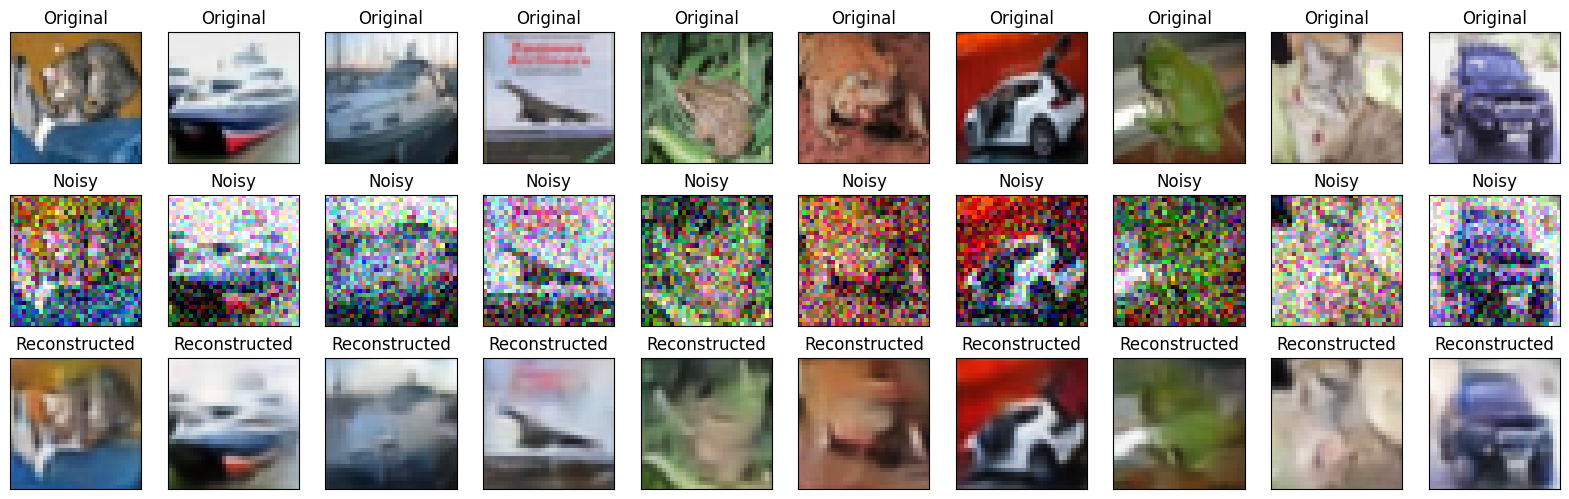

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from keras_tuner import RandomSearch
from skimage.metrics import structural_similarity as ssim

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add noise to datasets
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = x_test[:10] + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test[:10].shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Define a hypermodel
def build_model(hp):
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(hp.Int('input_units', min_value=32, max_value=128, step=32),
               (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = UpSampling2D((2, 2))(x)
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # Additional UpSampling2D layer
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                        loss='mean_squared_error')
    return autoencoder

# Initialize the tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='autoencoder_tuning',
    project_name='cifar10'
)

# Perform hyperparameter tuning
tuner.search(x_train_noisy, x_train, epochs=10, batch_size=128, validation_split=0.2)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the best hyperparameters
model = build_model(best_hps)
history = model.fit(x_train_noisy, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Evaluate Test Loss
test_loss = model.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.scatter(best_epoch, min(history.history['val_loss']), color='red')
plt.text(best_epoch, min(history.history['val_loss']), f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse = MeanSquaredError()
decoded_imgs = model.predict(x_test_noisy)
avg_mse = np.mean([mse(x_test[i], decoded_imgs[i]).numpy() for i in range(10)])
avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, noisy, and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


# **Table Generator**

In [19]:


# Build the model with the best hyperparameters
model = build_model(best_hps)

# Define a function to extract the details of each layer and integrate block type into layer type
def extract_layer_details(layer, block_num, is_decoder):
    layer_type = layer.__class__.__name__
    config = layer.get_config()

    # Defaults
    num_filters = '-'
    kernel_size = '-'
    strides = '-'
    activation = '-'
    batch_norm = 'NO'
    out_dim = 'x'.join(map(str, layer.output_shape[1:4])) if layer.output_shape[1:4] else '-'

    # Determine if the layer is part of a Conv or Deconv Block
    if isinstance(layer, Conv2D) or isinstance(layer, MaxPooling2D):
        block_label = 'Conv Block' if not is_decoder else 'Deconv Block'
        layer_type = f"{block_label} {block_num} - {layer_type}"

    # Extract details based on layer type
    if isinstance(layer, Conv2D):
        num_filters = config.get('filters', '-')
        kernel_size = 'x'.join(map(str, config.get('kernel_size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))
        activation = config.get('activation', '-')
    elif isinstance(layer, MaxPooling2D) or isinstance(layer, UpSampling2D):
        kernel_size = 'x'.join(map(str, config.get('size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))

    return [layer_type, num_filters, kernel_size, strides, activation, batch_norm, out_dim]

# Extract and print the layer details
block_num = 1
is_decoder = False
layer_details = []
for layer in model.layers:
    if isinstance(layer, MaxPooling2D):
        block_num += 1
    elif isinstance(layer, UpSampling2D):
        if not is_decoder:
            is_decoder = True
            block_num = 1
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))
        block_num += 1
    else:
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))

# Print the table
print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(
    "Init. Autoencoder", "Nr. Filters", "Kernel Size", "Strides", "Activation", "Batch Norm", "Output Dim"
))
for detail in layer_details:
    print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(*detail))


Init. Autoencoder                        Nr. Filters     Kernel Size     Strides    Activation      Batch Norm      Output Dim     
InputLayer                               -               -               -          -               NO              -              
Conv Block 1 - Conv2D                    96              3x3             1x1        relu            NO              32x32x96       
Conv Block 2 - Conv2D                    128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              16x16x128      
Deconv Block 2 - Conv2D                  128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              32x32x128      
Deconv Block 3 - Conv2D                  3               3x3             1x1

# **Random occlusion**

Epoch 1/50
391/391 [==============================] - 7s 14ms/step - loss: 0.0192 - val_loss: 0.0120
Epoch 2/50
391/391 [==============================] - 6s 14ms/step - loss: 0.0112 - val_loss: 0.0102
Epoch 3/50
391/391 [==============================] - 7s 17ms/step - loss: 0.0099 - val_loss: 0.0088
Epoch 4/50
391/391 [==============================] - 7s 18ms/step - loss: 0.0091 - val_loss: 0.0081
Epoch 5/50
391/391 [==============================] - 7s 17ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 6/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0078 - val_loss: 0.0069
Epoch 7/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0074 - val_loss: 0.0066
Epoch 8/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0072 - val_loss: 0.0063
Epoch 9/50
391/391 [==============================] - 5s 14ms/step - loss: 0.0069 - val_loss: 0.0062
Epoch 10/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0067 - val_lo

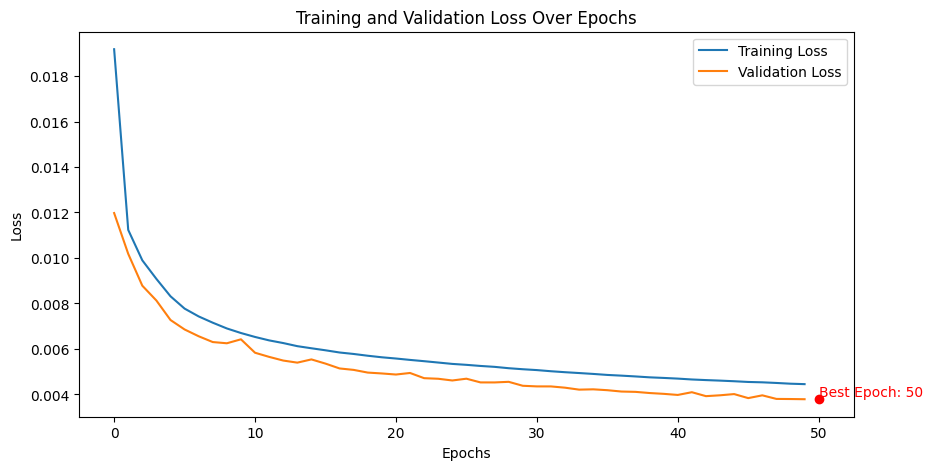

313/313 [==============================] - 1s 2ms/step


<ipython-input-7-aa02068b7ae0>:90: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  ssim_scores.append(ssim(x_test[i], decoded_images[i], multichannel=True))


Average MSE: 0.0037881737
Average SSIM: 0.86625075


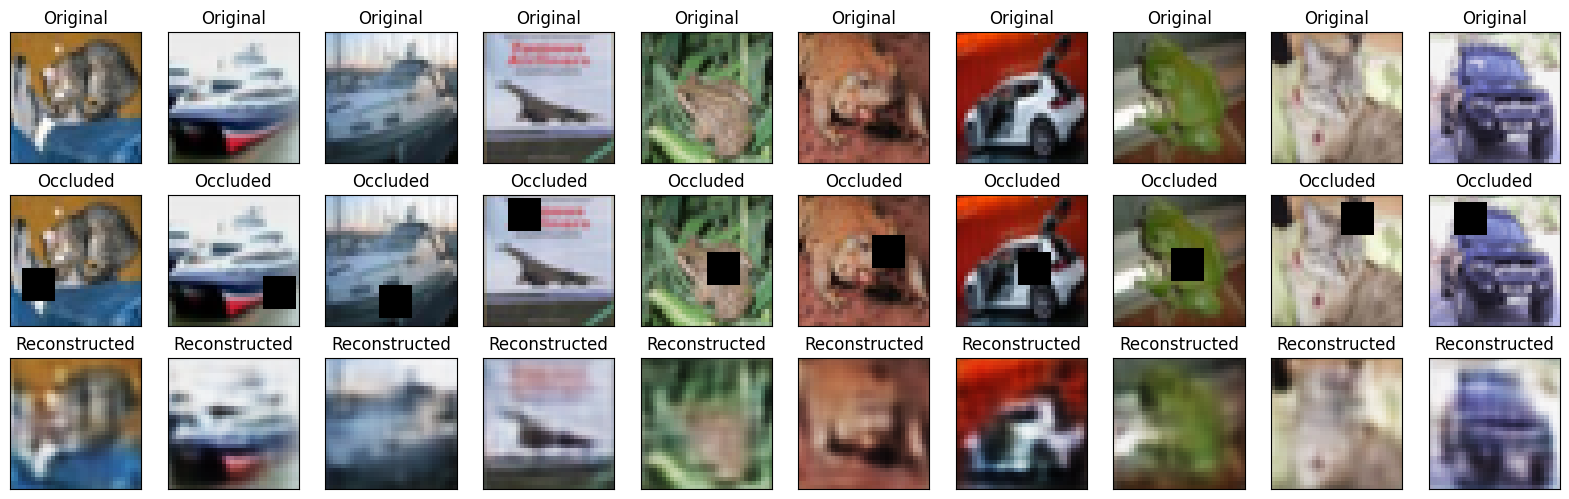

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.losses import MeanSquaredError

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Function to add random occlusions
def add_occlusions(images, occlusion_size=(8, 8)):
    occluded_images = images.copy()
    img_height, img_width = images.shape[1:3]

    for img in occluded_images:
        top_x = np.random.randint(0, img_width - occlusion_size[0])
        top_y = np.random.randint(0, img_height - occlusion_size[1])
        bottom_x = top_x + occlusion_size[0]
        bottom_y = top_y + occlusion_size[1]
        img[top_y:bottom_y, top_x:bottom_x, :] = 0
    return occluded_images

# Add occlusions to the training set and a subset of the test set
x_train_occluded = add_occlusions(x_train)
x_test_occluded = add_occlusions(x_test[:10])  # Occlude only the first 10 test images for display

# Define the autoencoder model
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # Bottleneck: now the data is (4, 4, 128)

# Decoder
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# Train the autoencoder with occluded data
history = autoencoder.fit(x_train_occluded, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Calculate Test Loss
test_loss = autoencoder.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Identify best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])

# Plot Training and Validation Loss Over Epochs
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.scatter(best_epoch, best_val_loss, color='red')  # Mark the best epoch
plt.text(best_epoch, best_val_loss, f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse_function = MeanSquaredError()
decoded_images = autoencoder.predict(x_test)
mse_scores, ssim_scores = [], []

for i in range(len(x_test)):
    mse_scores.append(mse_function(x_test[i], decoded_images[i]).numpy())
    ssim_scores.append(ssim(x_test[i], decoded_images[i], multichannel=True))

avg_mse = np.mean(mse_scores)
avg_ssim = np.mean(ssim_scores)
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, occluded, and reconstructed images
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display occluded images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_occluded[i])
    plt.title("Occluded")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_images[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


# **Hyper Parameter Tuning**

Reloading Tuner from autoencoder_occlusion_tuning/cifar10/tuner0.json
Epoch 1/50
391/391 [==============================] - 12s 26ms/step - loss: 0.0103 - val_loss: 0.0049
Epoch 2/50
391/391 [==============================] - 10s 24ms/step - loss: 0.0048 - val_loss: 0.0035
Epoch 3/50
391/391 [==============================] - 10s 25ms/step - loss: 0.0041 - val_loss: 0.0029
Epoch 4/50
391/391 [==============================] - 9s 24ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 5/50
391/391 [==============================] - 10s 25ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 6/50
391/391 [==============================] - 10s 24ms/step - loss: 0.0031 - val_loss: 0.0021
Epoch 7/50
391/391 [==============================] - 10s 26ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 8/50
391/391 [==============================] - 9s 24ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 9/50
391/391 [==============================] - 10s 24ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 10/50
39

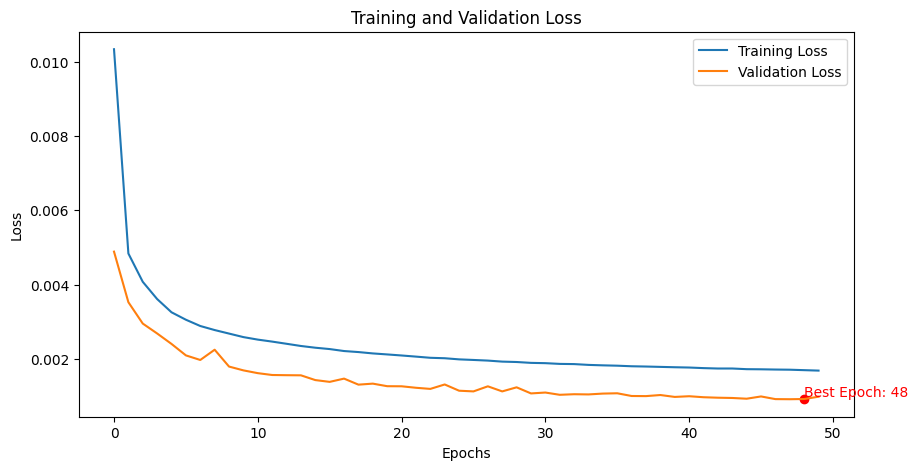

1/1 [==============================] - 0s 108ms/step
Average MSE: 0.001706196
Average SSIM: 0.9343136


<ipython-input-8-c240a72b580b>:104: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])


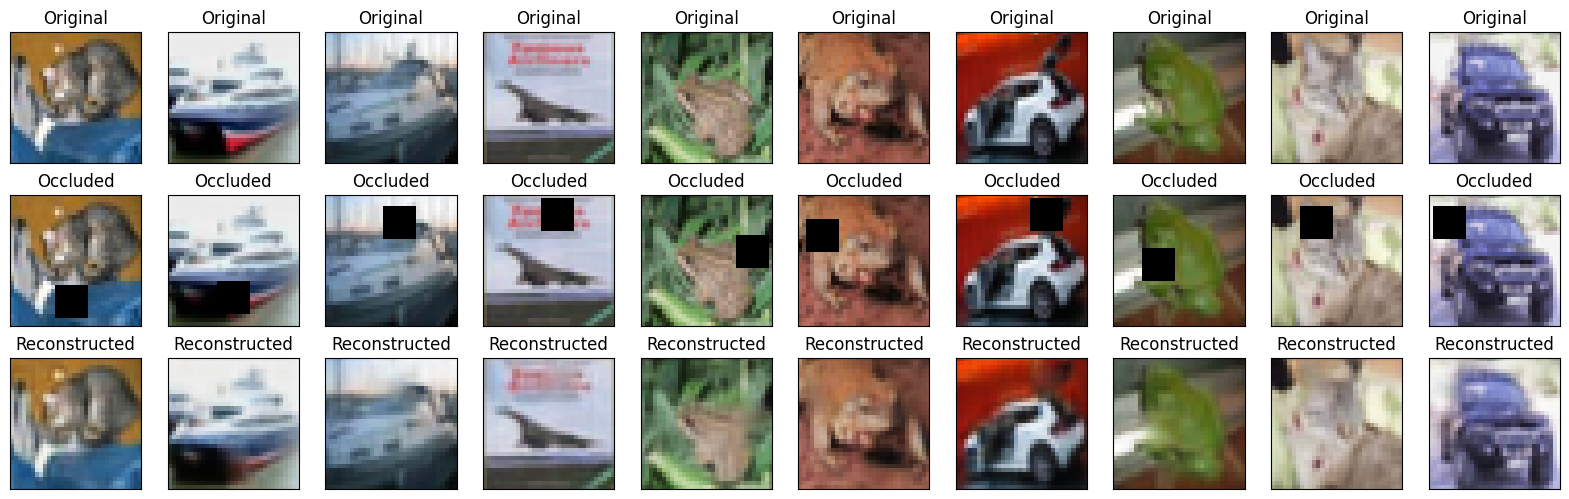

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from keras_tuner import RandomSearch
from skimage.metrics import structural_similarity as ssim

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Function to add random occlusions
def add_occlusions(images, occlusion_size=(8, 8)):
    occluded_images = images.copy()
    img_height, img_width = images.shape[1:3]

    for img in occluded_images:
        top_x = np.random.randint(0, img_width - occlusion_size[0])
        top_y = np.random.randint(0, img_height - occlusion_size[1])
        bottom_x = top_x + occlusion_size[0]
        bottom_y = top_y + occlusion_size[1]
        img[top_y:bottom_y, top_x:bottom_x, :] = 0
    return occluded_images

# Add occlusions to the training set and a subset of the test set
x_train_occluded = add_occlusions(x_train)
x_test_occluded = add_occlusions(x_test[:10])  # Occlude only the first 10 test images for display

# Define a hypermodel
def build_model(hp):
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(hp.Int('input_units', min_value=32, max_value=128, step=32),
               (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = UpSampling2D((2, 2))(x)
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # Additional UpSampling2D layer
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                        loss='mean_squared_error')
    return autoencoder

# Initialize the tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='autoencoder_occlusion_tuning',
    project_name='cifar10'
)

# Perform hyperparameter tuning
tuner.search(x_train_occluded, x_train, epochs=10, batch_size=128, validation_split=0.2)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the best hyperparameters
model = build_model(best_hps)
history = model.fit(x_train_occluded, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Evaluate Test Loss
test_loss = model.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.scatter(best_epoch, min(history.history['val_loss']), color='red')
plt.text(best_epoch, min(history.history['val_loss']), f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse = MeanSquaredError()
decoded_imgs = model.predict(x_test_occluded)
avg_mse = np.mean([mse(x_test[i], decoded_imgs[i]).numpy() for i in range(10)])
avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, occluded, and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display occluded images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_occluded[i])
    plt.title("Occluded")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


# **Table Generator**

In [18]:


# Build the model with the best hyperparameters
model = build_model(best_hps)

# Define a function to extract the details of each layer and integrate block type into layer type
def extract_layer_details(layer, block_num, is_decoder):
    layer_type = layer.__class__.__name__
    config = layer.get_config()

    # Defaults
    num_filters = '-'
    kernel_size = '-'
    strides = '-'
    activation = '-'
    batch_norm = 'NO'
    out_dim = 'x'.join(map(str, layer.output_shape[1:4])) if layer.output_shape[1:4] else '-'

    # Determine if the layer is part of a Conv or Deconv Block
    if isinstance(layer, Conv2D) or isinstance(layer, MaxPooling2D):
        block_label = 'Conv Block' if not is_decoder else 'Deconv Block'
        layer_type = f"{block_label} {block_num} - {layer_type}"

    # Extract details based on layer type
    if isinstance(layer, Conv2D):
        num_filters = config.get('filters', '-')
        kernel_size = 'x'.join(map(str, config.get('kernel_size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))
        activation = config.get('activation', '-')
    elif isinstance(layer, MaxPooling2D) or isinstance(layer, UpSampling2D):
        kernel_size = 'x'.join(map(str, config.get('size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))

    return [layer_type, num_filters, kernel_size, strides, activation, batch_norm, out_dim]

# Extract and print the layer details
block_num = 1
is_decoder = False
layer_details = []
for layer in model.layers:
    if isinstance(layer, MaxPooling2D):
        block_num += 1
    elif isinstance(layer, UpSampling2D):
        if not is_decoder:
            is_decoder = True
            block_num = 1
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))
        block_num += 1
    else:
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))

# Print the table
print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(
    "Init. Autoencoder", "Nr. Filters", "Kernel Size", "Strides", "Activation", "Batch Norm", "Output Dim"
))
for detail in layer_details:
    print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(*detail))


Init. Autoencoder                        Nr. Filters     Kernel Size     Strides    Activation      Batch Norm      Output Dim     
InputLayer                               -               -               -          -               NO              -              
Conv Block 1 - Conv2D                    96              3x3             1x1        relu            NO              32x32x96       
Conv Block 2 - Conv2D                    128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              16x16x128      
Deconv Block 2 - Conv2D                  128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              32x32x128      
Deconv Block 3 - Conv2D                  3               3x3             1x1

# **Combined Model Performance**

Epoch 1/50
391/391 [==============================] - 7s 14ms/step - loss: 0.0189 - val_loss: 0.0735
Epoch 2/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0127 - val_loss: 0.0560
Epoch 3/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0114 - val_loss: 0.0528
Epoch 4/50
391/391 [==============================] - 5s 12ms/step - loss: 0.0106 - val_loss: 0.0433
Epoch 5/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0099 - val_loss: 0.0402
Epoch 6/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0095 - val_loss: 0.0363
Epoch 7/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0092 - val_loss: 0.0348
Epoch 8/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0089 - val_loss: 0.0302
Epoch 9/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0087 - val_loss: 0.0257
Epoch 10/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0085 - val_lo

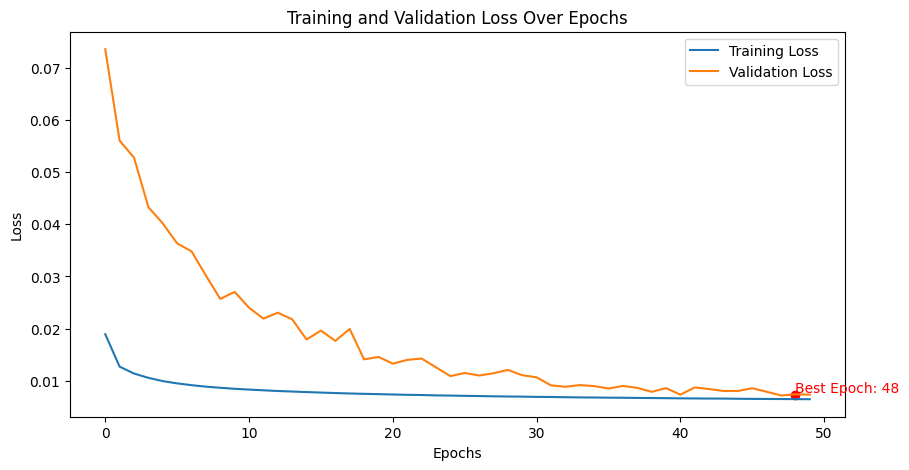

1/1 [==============================] - 0s 138ms/step
Average MSE: 0.006792473
Average SSIM: 0.7468698


<ipython-input-9-26d4ff7105bd>:99: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  ssim_scores.append(ssim(x_test[i], decoded_images[i], multichannel=True))


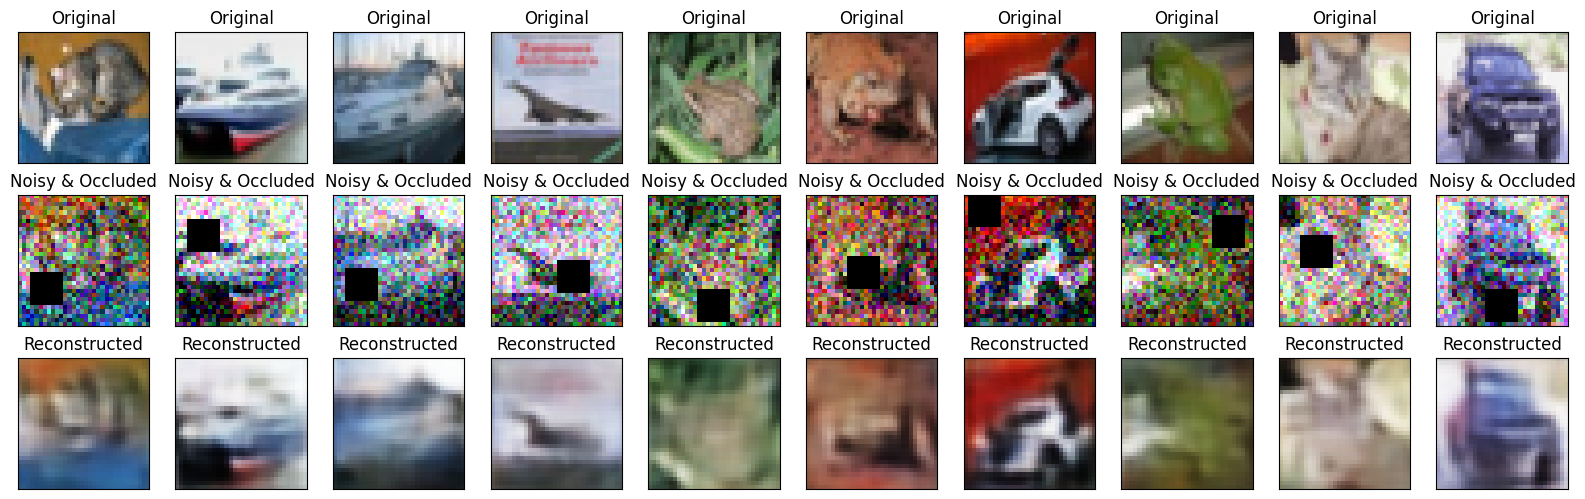

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.losses import MeanSquaredError

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Additive Gaussian noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# Function to add random occlusions
def add_occlusions(images, occlusion_size=(8, 8)):
    occluded_images = images.copy()
    img_height, img_width = images.shape[1:3]

    for img in occluded_images:
        top_x = np.random.randint(0, img_width - occlusion_size[0])
        top_y = np.random.randint(0, img_height - occlusion_size[1])
        bottom_x = top_x + occlusion_size[0]
        bottom_y = top_y + occlusion_size[1]
        img[top_y:bottom_y, top_x:bottom_x, :] = 0
    return occluded_images

# Apply occlusions to the noisy images
x_train_noisy_occluded = add_occlusions(x_train_noisy)

# Create noisy and occluded test images
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
x_test_noisy_occluded = add_occlusions(x_test_noisy)[:10]  # Occlude first 10 test images for display

# Define the autoencoder model
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # Bottleneck: now the data is (4, 4, 128)

# Decoder
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# Train the autoencoder with noisy and occluded data
history = autoencoder.fit(x_train_noisy_occluded, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Evaluate Test Loss
test_loss = autoencoder.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Identify best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])

# Plot Training and Validation Loss Over Epochs
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.scatter(best_epoch, best_val_loss, color='red')  # Mark the best epoch
plt.text(best_epoch, best_val_loss, f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse_function = MeanSquaredError()
decoded_images = autoencoder.predict(x_test_noisy_occluded)
mse_scores, ssim_scores = [], []

for i in range(10):
    mse_scores.append(mse_function(x_test[i], decoded_images[i]).numpy())
    ssim_scores.append(ssim(x_test[i], decoded_images[i], multichannel=True))

avg_mse = np.mean(mse_scores)
avg_ssim = np.mean(ssim_scores)
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, noisy and occluded, and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy and occluded images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy_occluded[i])
    plt.title("Noisy & Occluded")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_images[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


# **Hyper Parameter Tuning**

Reloading Tuner from autoencoder_noise_occlusion_tuning/cifar10/tuner0.json
Epoch 1/50
391/391 [==============================] - 11s 24ms/step - loss: 0.0136 - val_loss: 0.0346
Epoch 2/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0075 - val_loss: 0.0148
Epoch 3/50
391/391 [==============================] - 11s 28ms/step - loss: 0.0067 - val_loss: 0.0129
Epoch 4/50
391/391 [==============================] - 10s 25ms/step - loss: 0.0063 - val_loss: 0.0148
Epoch 5/50
391/391 [==============================] - 10s 24ms/step - loss: 0.0060 - val_loss: 0.0074
Epoch 6/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0058 - val_loss: 0.0076
Epoch 7/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0057 - val_loss: 0.0065
Epoch 8/50
391/391 [==============================] - 9s 22ms/step - loss: 0.0056 - val_loss: 0.0064
Epoch 9/50
391/391 [==============================] - 9s 23ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 10/50

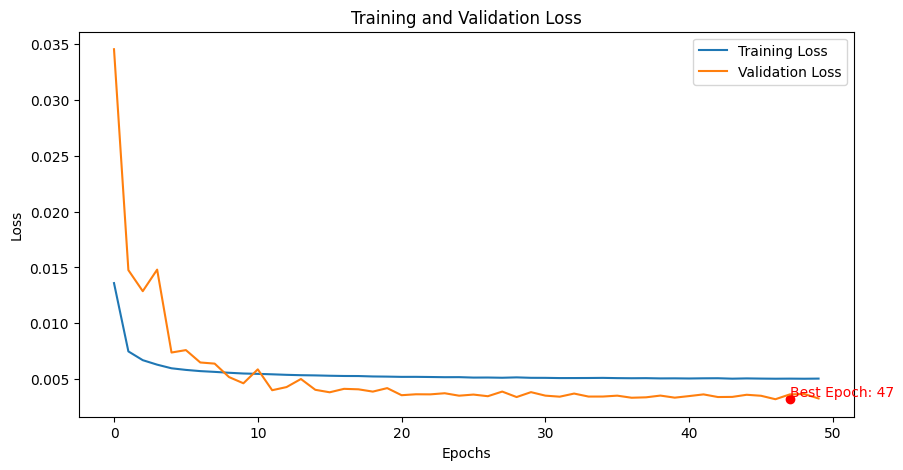

1/1 [==============================] - 0s 72ms/step
Average MSE: 0.005157408
Average SSIM: 0.7929887


<ipython-input-10-19905c595233>:113: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])


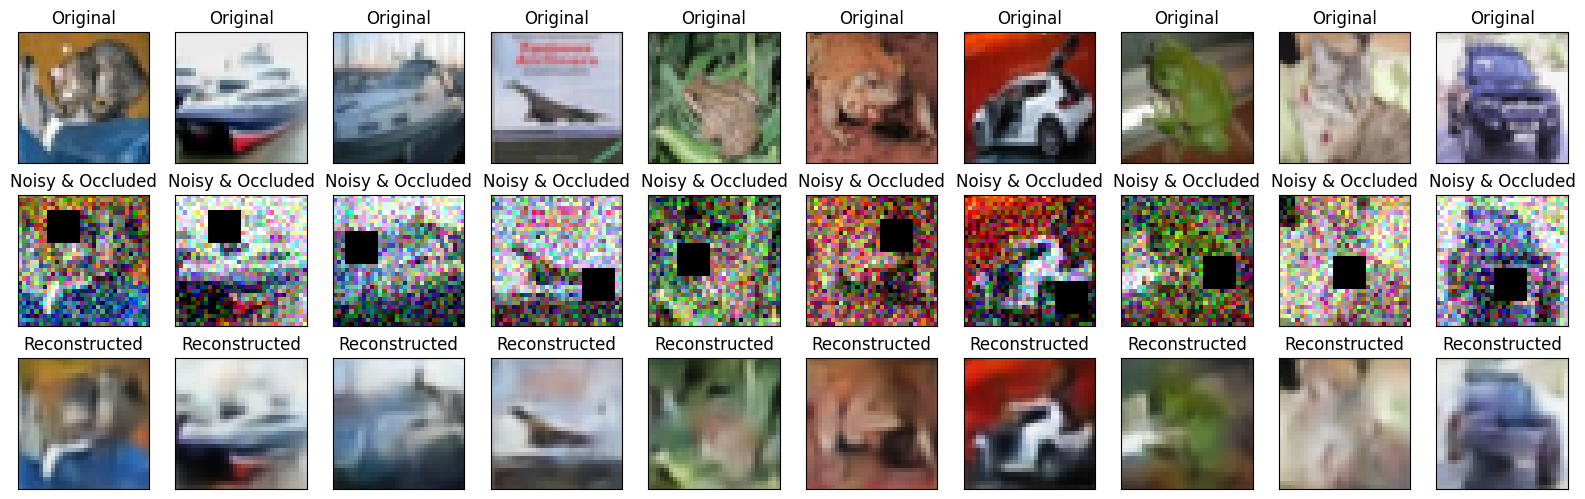

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from keras_tuner import RandomSearch
from skimage.metrics import structural_similarity as ssim

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Additive Gaussian noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# Function to add random occlusions
def add_occlusions(images, occlusion_size=(8, 8)):
    occluded_images = images.copy()
    img_height, img_width = images.shape[1:3]

    for img in occluded_images:
        top_x = np.random.randint(0, img_width - occlusion_size[0])
        top_y = np.random.randint(0, img_height - occlusion_size[1])
        bottom_x = top_x + occlusion_size[0]
        bottom_y = top_y + occlusion_size[1]
        img[top_y:bottom_y, top_x:bottom_x, :] = 0
    return occluded_images

# Apply occlusions to the noisy images
x_train_noisy_occluded = add_occlusions(x_train_noisy)

# Create noisy and occluded test images
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
x_test_noisy_occluded = add_occlusions(x_test_noisy)[:10]  # Occlude first 10 test images for display

# Define a hypermodel
def build_model(hp):
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(hp.Int('input_units', min_value=32, max_value=128, step=32),
               (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        x = UpSampling2D((2, 2))(x)
        x = Conv2D(hp.Int(f'conv_{i}_units', min_value=32, max_value=128, step=32),
                   (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # Additional UpSampling2D layer
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                        loss='mean_squared_error')
    return autoencoder

# Initialize the tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='autoencoder_noise_occlusion_tuning',
    project_name='cifar10'
)

# Perform hyperparameter tuning
tuner.search(x_train_noisy_occluded, x_train, epochs=10, batch_size=128, validation_split=0.2)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the best hyperparameters
model = build_model(best_hps)
history = model.fit(x_train_noisy_occluded, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Evaluate Test Loss
test_loss = model.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

# Print the Validation Loss
validation_loss = history.history['val_loss'][-1]
print("Validation Loss:", validation_loss)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.scatter(best_epoch, min(history.history['val_loss']), color='red')
plt.text(best_epoch, min(history.history['val_loss']), f'Best Epoch: {best_epoch}', color='red', va='bottom')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate MSE and SSIM
mse = MeanSquaredError()
decoded_imgs = model.predict(x_test_noisy_occluded)
avg_mse = np.mean([mse(x_test[i], decoded_imgs[i]).numpy() for i in range(10)])
avg_ssim = np.mean([ssim(x_test[i], decoded_imgs[i], multichannel=True) for i in range(10)])
print("Average MSE:", avg_mse)
print("Average SSIM:", avg_ssim)

# Display original, noisy and occluded, and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy and occluded images
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy_occluded[i])
    plt.title("Noisy & Occluded")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


# **Table Gnerator**

In [17]:
# [Your existing imports and code]

# Build the model with the best hyperparameters
model = build_model(best_hps)

# Define a function to extract the details of each layer and integrate block type into layer type
def extract_layer_details(layer, block_num, is_decoder):
    layer_type = layer.__class__.__name__
    config = layer.get_config()

    # Defaults
    num_filters = '-'
    kernel_size = '-'
    strides = '-'
    activation = '-'
    batch_norm = 'NO'
    out_dim = 'x'.join(map(str, layer.output_shape[1:4])) if layer.output_shape[1:4] else '-'

    # Determine if the layer is part of a Conv or Deconv Block
    if isinstance(layer, Conv2D) or isinstance(layer, MaxPooling2D):
        block_label = 'Conv Block' if not is_decoder else 'Deconv Block'
        layer_type = f"{block_label} {block_num} - {layer_type}"

    # Extract details based on layer type
    if isinstance(layer, Conv2D):
        num_filters = config.get('filters', '-')
        kernel_size = 'x'.join(map(str, config.get('kernel_size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))
        activation = config.get('activation', '-')
    elif isinstance(layer, MaxPooling2D) or isinstance(layer, UpSampling2D):
        kernel_size = 'x'.join(map(str, config.get('size', '-')))
        strides = 'x'.join(map(str, config.get('strides', '-')))

    return [layer_type, num_filters, kernel_size, strides, activation, batch_norm, out_dim]

# Extract and print the layer details
block_num = 1
is_decoder = False
layer_details = []
for layer in model.layers:
    if isinstance(layer, MaxPooling2D):
        block_num += 1
    elif isinstance(layer, UpSampling2D):
        if not is_decoder:
            is_decoder = True
            block_num = 1
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))
        block_num += 1
    else:
        layer_details.append(extract_layer_details(layer, block_num, is_decoder))

# Print the table
print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(
    "Init. Autoencoder", "Nr. Filters", "Kernel Size", "Strides", "Activation", "Batch Norm", "Output Dim"
))
for detail in layer_details:
    print("{:<40} {:<15} {:<15} {:<10} {:<15} {:<15} {:<15}".format(*detail))


Init. Autoencoder                        Nr. Filters     Kernel Size     Strides    Activation      Batch Norm      Output Dim     
InputLayer                               -               -               -          -               NO              -              
Conv Block 1 - Conv2D                    96              3x3             1x1        relu            NO              32x32x96       
Conv Block 2 - Conv2D                    128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              16x16x128      
Deconv Block 2 - Conv2D                  128             3x3             1x1        relu            NO              16x16x128      
UpSampling2D                             -               2x2             -          -               NO              32x32x128      
Deconv Block 3 - Conv2D                  3               3x3             1x1